In [1]:
import pandas as pd
import joblib
import shap

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
model = joblib.load('../models/credit_risk_model.pkl')

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test.sample(1000, random_state=42))

In [2]:
import os
os.getcwd()

'C:\\Users\\91988\\credit-risk-prediction\\notebooks'

In [3]:
import os
print(os.listdir('../data/processed'))

['X_test.csv', 'X_train.csv', 'y_test.csv', 'y_train.csv']


In [4]:
import pandas as pd
import joblib
import shap

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
model = joblib.load('../models/credit_risk_model.pkl')

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test.sample(1000, random_state=42))

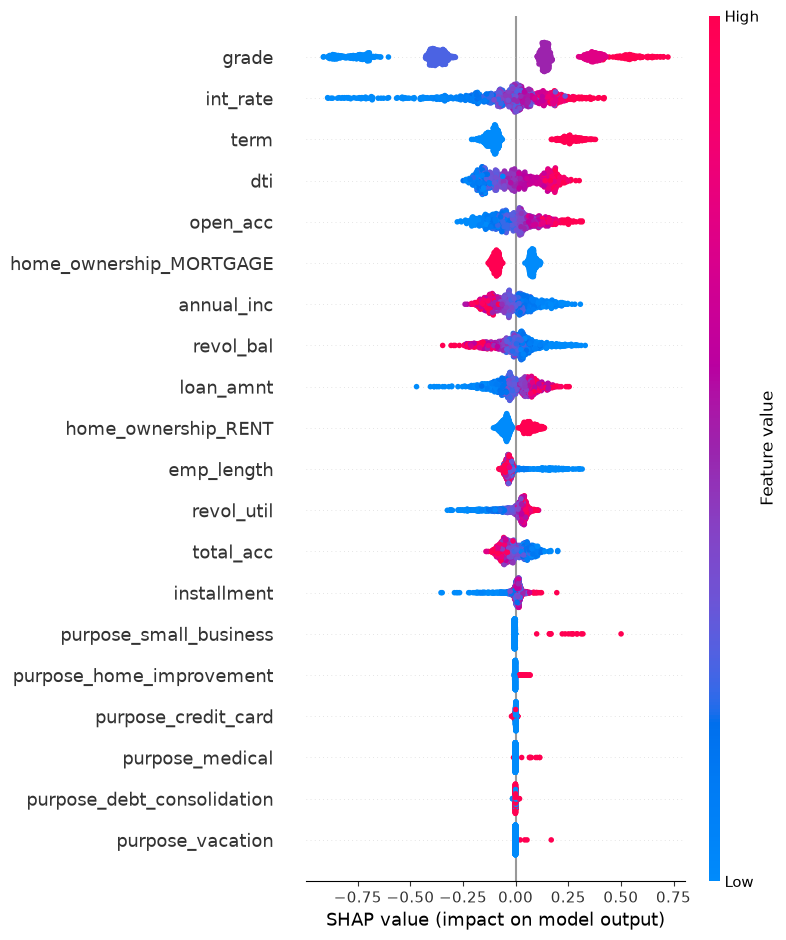

In [5]:
shap.summary_plot(shap_values, X_test.sample(1000, random_state=42))

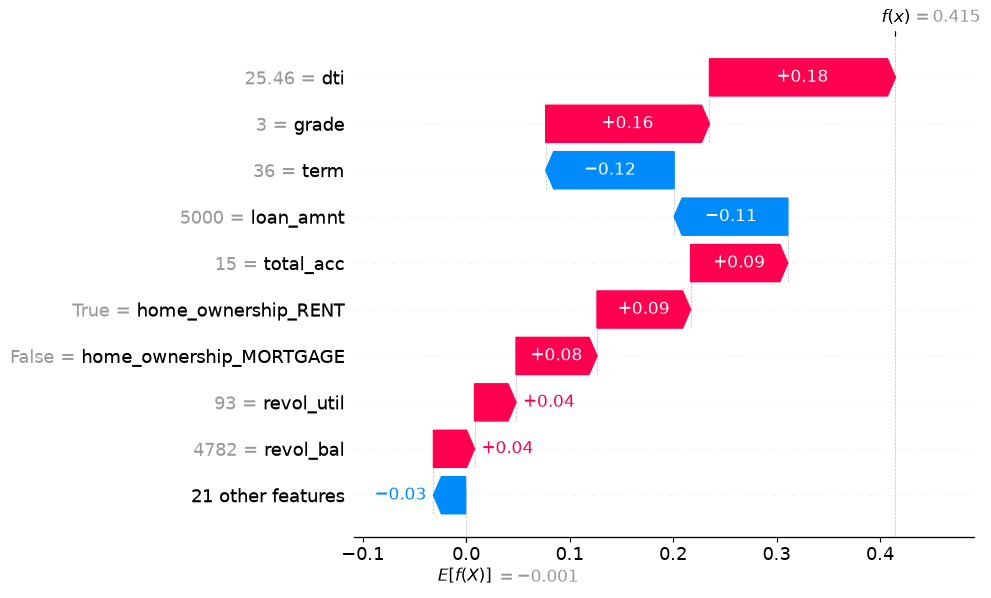

In [6]:
sample = X_test.sample(1000, random_state=42)
single_explainer = shap.Explainer(model)
single_shap = single_explainer(sample.iloc[[0]])
shap.plots.waterfall(single_shap[0])

In [8]:
import sys
sys.path.append('../src')
from explain import explain_prediction

feature_cols = list(X_train.columns)
result = explain_prediction(model, X_test.iloc[[0]], feature_cols)
result

ModuleNotFoundError: No module named 'explain'

In [9]:
import os
print(os.listdir('../src'))

[]


In [10]:
code = '''import shap

def explain_prediction(model, input_df, feature_cols):
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(input_df[feature_cols])[0]
    impacts = sorted(zip(feature_cols, shap_vals), key=lambda x: abs(x[1]), reverse=True)[:5]
    return [{"feature": f, "impact": round(float(v), 3)} for f, v in impacts]
'''

with open('../src/explain.py', 'w') as f:
    f.write(code)

print("saved")

saved


In [11]:
import os
print(os.listdir('../src'))

['explain.py']


In [12]:
import sys
sys.path.append('../src')
from explain import explain_prediction

feature_cols = list(X_train.columns)
result = explain_prediction(model, X_test.iloc[[0]], feature_cols)
result

[{'feature': 'grade', 'impact': -0.379},
 {'feature': 'loan_amnt', 'impact': 0.142},
 {'feature': 'revol_bal', 'impact': 0.101},
 {'feature': 'term', 'impact': -0.097},
 {'feature': 'home_ownership_MORTGAGE', 'impact': 0.084}]

In [13]:
api_code = '''from fastapi import FastAPI
import joblib, pandas as pd
import sys, os
sys.path.append(os.path.join(os.path.dirname(__file__), "..", "src"))
from explain import explain_prediction

app = FastAPI()
model = joblib.load(os.path.join(os.path.dirname(__file__), "..", "models", "credit_risk_model.pkl"))
feature_cols = joblib.load(os.path.join(os.path.dirname(__file__), "..", "models", "feature_columns.pkl"))

@app.post("/predict")
def predict(data: dict):
    df = pd.DataFrame([data])[feature_cols]
    prob = float(model.predict_proba(df)[0][1])
    risk = "High" if prob > 0.5 else "Medium" if prob > 0.2 else "Low"
    factors = explain_prediction(model, df, feature_cols)
    return {"default_probability": round(prob, 2), "risk_category": risk, "top_factors": factors}
'''

with open('../api/main.py', 'w') as f:
    f.write(api_code)

print("saved")

saved


In [14]:
import os
print(os.listdir('../api'))

['main.py']


In [20]:
import pandas as pd
X_test = pd.read_csv('../data/processed/X_test.csv')
print(X_test.iloc[0].to_dict())

{'loan_amnt': 20000, 'term': 36, 'int_rate': 12.49, 'installment': 668.98, 'grade': 2, 'emp_length': 10.0, 'annual_inc': 80000.0, 'dti': 16.4, 'open_acc': 13.0, 'revol_bal': 8421, 'revol_util': 42.5, 'total_acc': 34.0, 'home_ownership_MORTGAGE': False, 'home_ownership_NONE': False, 'home_ownership_OTHER': False, 'home_ownership_OWN': False, 'home_ownership_RENT': True, 'purpose_credit_card': False, 'purpose_debt_consolidation': True, 'purpose_educational': False, 'purpose_home_improvement': False, 'purpose_house': False, 'purpose_major_purchase': False, 'purpose_medical': False, 'purpose_moving': False, 'purpose_other': False, 'purpose_renewable_energy': False, 'purpose_small_business': False, 'purpose_vacation': False, 'purpose_wedding': False}


In [21]:
app_code = '''import streamlit as st
import requests

st.title("Loan Risk Assessment")

loan_amnt = st.number_input("Loan Amount", min_value=0, value=15000)
term = st.selectbox("Term (months)", [36, 60])
int_rate = st.number_input("Interest Rate (%)", min_value=0.0, value=12.5)
installment = st.number_input("Monthly Installment", min_value=0.0, value=500.0)
grade = st.selectbox("Credit Grade (1=A best, 7=G worst)", [1,2,3,4,5,6,7], index=1)
emp_length = st.slider("Employment Length (years)", 0, 10, 5)
annual_inc = st.number_input("Annual Income", min_value=0.0, value=60000.0)
dti = st.number_input("Debt-to-Income Ratio", min_value=0.0, value=15.0)
open_acc = st.number_input("Open Credit Lines", min_value=0.0, value=10.0)
revol_bal = st.number_input("Revolving Balance", min_value=0, value=8000)
revol_util = st.number_input("Revolving Utilization (%)", min_value=0.0, value=40.0)
total_acc = st.number_input("Total Credit Lines", min_value=0.0, value=25.0)
home_ownership = st.selectbox("Home Ownership", ["MORTGAGE", "RENT", "OWN", "OTHER", "NONE"])
purpose = st.selectbox("Loan Purpose", ["debt_consolidation", "credit_card", "home_improvement",
    "major_purchase", "medical", "small_business", "vacation", "wedding", "moving",
    "house", "renewable_energy", "educational", "other"])

if st.button("Assess Risk"):
    payload = {
        "loan_amnt": loan_amnt, "term": term, "int_rate": int_rate, "installment": installment,
        "grade": grade, "emp_length": float(emp_length), "annual_inc": annual_inc, "dti": dti,
        "open_acc": open_acc, "revol_bal": revol_bal, "revol_util": revol_util, "total_acc": total_acc,
        "home_ownership_MORTGAGE": home_ownership == "MORTGAGE",
        "home_ownership_NONE": home_ownership == "NONE",
        "home_ownership_OTHER": home_ownership == "OTHER",
        "home_ownership_OWN": home_ownership == "OWN",
        "home_ownership_RENT": home_ownership == "RENT",
        "purpose_credit_card": purpose == "credit_card",
        "purpose_debt_consolidation": purpose == "debt_consolidation",
        "purpose_educational": purpose == "educational",
        "purpose_home_improvement": purpose == "home_improvement",
        "purpose_house": purpose == "house",
        "purpose_major_purchase": purpose == "major_purchase",
        "purpose_medical": purpose == "medical",
        "purpose_moving": purpose == "moving",
        "purpose_other": purpose == "other",
        "purpose_renewable_energy": purpose == "renewable_energy",
        "purpose_small_business": purpose == "small_business",
        "purpose_vacation": purpose == "vacation",
        "purpose_wedding": purpose == "wedding",
    }
    response = requests.post("http://127.0.0.1:8000/predict", json=payload)
    result = response.json()
    st.metric("Default Probability", f"{result[\\'default_probability\\']*100:.1f}%")
    st.write("Risk Category:", result[\\'risk_category\\'])
    st.bar_chart({f[\\'feature\\']: f[\\'impact\\'] for f in result[\\'top_factors\\']})
'''

with open('../app/app.py', 'w') as f:
    f.write(app_code)

print("saved")

saved


In [22]:
app_code = '''import streamlit as st
import requests

st.title("Loan Risk Assessment")

loan_amnt = st.number_input("Loan Amount", min_value=0, value=15000)
term = st.selectbox("Term (months)", [36, 60])
int_rate = st.number_input("Interest Rate (%)", min_value=0.0, value=12.5)
installment = st.number_input("Monthly Installment", min_value=0.0, value=500.0)
grade = st.selectbox("Credit Grade (1=A best, 7=G worst)", [1,2,3,4,5,6,7], index=1)
emp_length = st.slider("Employment Length (years)", 0, 10, 5)
annual_inc = st.number_input("Annual Income", min_value=0.0, value=60000.0)
dti = st.number_input("Debt-to-Income Ratio", min_value=0.0, value=15.0)
open_acc = st.number_input("Open Credit Lines", min_value=0.0, value=10.0)
revol_bal = st.number_input("Revolving Balance", min_value=0, value=8000)
revol_util = st.number_input("Revolving Utilization (%)", min_value=0.0, value=40.0)
total_acc = st.number_input("Total Credit Lines", min_value=0.0, value=25.0)
home_ownership = st.selectbox("Home Ownership", ["MORTGAGE", "RENT", "OWN", "OTHER", "NONE"])
purpose = st.selectbox("Loan Purpose", ["debt_consolidation", "credit_card", "home_improvement",
    "major_purchase", "medical", "small_business", "vacation", "wedding", "moving",
    "house", "renewable_energy", "educational", "other"])

if st.button("Assess Risk"):
    payload = {
        "loan_amnt": loan_amnt, "term": term, "int_rate": int_rate, "installment": installment,
        "grade": grade, "emp_length": float(emp_length), "annual_inc": annual_inc, "dti": dti,
        "open_acc": open_acc, "revol_bal": revol_bal, "revol_util": revol_util, "total_acc": total_acc,
        "home_ownership_MORTGAGE": home_ownership == "MORTGAGE",
        "home_ownership_NONE": home_ownership == "NONE",
        "home_ownership_OTHER": home_ownership == "OTHER",
        "home_ownership_OWN": home_ownership == "OWN",
        "home_ownership_RENT": home_ownership == "RENT",
        "purpose_credit_card": purpose == "credit_card",
        "purpose_debt_consolidation": purpose == "debt_consolidation",
        "purpose_educational": purpose == "educational",
        "purpose_home_improvement": purpose == "home_improvement",
        "purpose_house": purpose == "house",
        "purpose_major_purchase": purpose == "major_purchase",
        "purpose_medical": purpose == "medical",
        "purpose_moving": purpose == "moving",
        "purpose_other": purpose == "other",
        "purpose_renewable_energy": purpose == "renewable_energy",
        "purpose_small_business": purpose == "small_business",
        "purpose_vacation": purpose == "vacation",
        "purpose_wedding": purpose == "wedding",
    }
    response = requests.post("http://127.0.0.1:8000/predict", json=payload)

_IncompleteInputError: incomplete input (686584141.py, line 1)

In [23]:
app_code = '''import streamlit as st
import requests

st.title("Loan Risk Assessment")

loan_amnt = st.number_input("Loan Amount", min_value=0, value=15000)
term = st.selectbox("Term (months)", [36, 60])
int_rate = st.number_input("Interest Rate (%)", min_value=0.0, value=12.5)
installment = st.number_input("Monthly Installment", min_value=0.0, value=500.0)
grade = st.selectbox("Credit Grade (1=A best, 7=G worst)", [1,2,3,4,5,6,7], index=1)
emp_length = st.slider("Employment Length (years)", 0, 10, 5)
annual_inc = st.number_input("Annual Income", min_value=0.0, value=60000.0)
dti = st.number_input("Debt-to-Income Ratio", min_value=0.0, value=15.0)
open_acc = st.number_input("Open Credit Lines", min_value=0.0, value=10.0)
revol_bal = st.number_input("Revolving Balance", min_value=0, value=8000)
revol_util = st.number_input("Revolving Utilization (%)", min_value=0.0, value=40.0)
total_acc = st.number_input("Total Credit Lines", min_value=0.0, value=25.0)
home_ownership = st.selectbox("Home Ownership", ["MORTGAGE", "RENT", "OWN", "OTHER", "NONE"])
purpose = st.selectbox("Loan Purpose", ["debt_consolidation", "credit_card", "home_improvement",
    "major_purchase", "medical", "small_business", "vacation", "wedding", "moving",
    "house", "renewable_energy", "educational", "other"])

if st.button("Assess Risk"):
    payload = {
        "loan_amnt": loan_amnt, "term": term, "int_rate": int_rate, "installment": installment,
        "grade": grade, "emp_length": float(emp_length), "annual_inc": annual_inc, "dti": dti,
        "open_acc": open_acc, "revol_bal": revol_bal, "revol_util": revol_util, "total_acc": total_acc,
        "home_ownership_MORTGAGE": home_ownership == "MORTGAGE",
        "home_ownership_NONE": home_ownership == "NONE",
        "home_ownership_OTHER": home_ownership == "OTHER",
        "home_ownership_OWN": home_ownership == "OWN",
        "home_ownership_RENT": home_ownership == "RENT",
        "purpose_credit_card": purpose == "credit_card",
        "purpose_debt_consolidation": purpose == "debt_consolidation",
        "purpose_educational": purpose == "educational",
        "purpose_home_improvement": purpose == "home_improvement",
        "purpose_house": purpose == "house",
        "purpose_major_purchase": purpose == "major_purchase",
        "purpose_medical": purpose == "medical",
        "purpose_moving": purpose == "moving",
        "purpose_other": purpose == "other",
        "purpose_renewable_energy": purpose == "renewable_energy",
        "purpose_small_business": purpose == "small_business",
        "purpose_vacation": purpose == "vacation",
        "purpose_wedding": purpose == "wedding",
    }
    response = requests.post("http://127.0.0.1:8000/predict", json=payload)
    result = response.json()

    prob = result["default_probability"]
    risk = result["risk_category"]
    factors = result["top_factors"]

    st.metric("Default Probability", f"{prob*100:.1f}%")
    st.write("Risk Category:", risk)

    chart_data = {}
    for f in factors:
        chart_data[f["feature"]] = f["impact"]
    st.bar_chart(chart_data)
'''

with open('../app/app.py', 'w') as f:
    f.write(app_code)

print("saved")

saved


In [24]:
gitignore_content = '''venv/
data/raw/
data/processed/
.ipynb_checkpoints/
__pycache__/
'''
with open('../.gitignore', 'w') as f:
    f.write(gitignore_content)
print("updated")

updated


In [25]:
api_requirements = '''fastapi==0.115.0
uvicorn==0.30.6
pandas==2.2.2
scikit-learn==1.5.1
xgboost==2.1.1
shap==0.46.0
joblib==1.4.2
'''
with open('../api/requirements.txt', 'w') as f:
    f.write(api_requirements)
print("saved")

saved


In [26]:
runtime_content = "python-3.11.9\n"
with open('../api/runtime.txt', 'w') as f:
    f.write(runtime_content)
print("saved")

saved


In [27]:
api_requirements = '''fastapi>=0.115.0
uvicorn>=0.30.6
pandas>=2.2.0
scikit-learn>=1.5.0
xgboost>=2.1.0
shap>=0.46.0
joblib>=1.4.0
'''
with open('../api/requirements.txt', 'w') as f:
    f.write(api_requirements)
print("saved")

saved


In [28]:
render_url = "https://YOUR_RENDER_URL.onrender.com/predict"  # <-- replace this

with open('../app/app.py', 'r') as f:
    content = f.read()

content = content.replace('https://credit-risk-api-piug.onrender.com/docs', render_url)

with open('../app/app.py', 'w') as f:
    f.write(content)

print("updated")

updated


In [29]:
streamlit_requirements = '''streamlit>=1.38.0
requests>=2.32.0
'''
with open('../app/requirements.txt', 'w') as f:
    f.write(streamlit_requirements)
print("saved")

saved


In [30]:
readme_content = '''# Credit Risk & Loan Default Prediction with Explainability

A machine learning system that predicts the probability a loan applicant will default, and explains *why* using SHAP - built as a Streamlit web app backed by a FastAPI service.

## Live Demo
- App: [YOUR_STREAMLIT_URL_HERE]
- API docs: [YOUR_RENDER_URL_HERE]/docs

## Problem Statement
Lenders need to assess the risk of a loan applicant defaulting - but a black-box "yes/no" isn't enough for real decision-making or regulatory transparency. This project predicts default probability and explains which factors drove each prediction.

## Dataset
- Source: Lending Club Loan Data (Kaggle)
- Size: ~1.3 million loans with a known final outcome
- Target definition: Loans were filtered to only Fully Paid (repaid, target = 0) and Charged Off (defaulted, target = 1). Loans still Current, Late, or In Grace Period were excluded, since their outcome isn't known yet - including them would leak future information into the model.

## Approach
1. Loaded and cleaned ~1.3M rows, selecting 15+ features known at application time
2. Encoded categorical features, handled missing values, split into train/test sets (stratified 80/20)
3. Trained and compared four models
4. Tuned the best model with RandomizedSearchCV
5. Added SHAP explainability to break down individual predictions
6. Built a FastAPI backend serving predictions plus explanations
7. Built a Streamlit frontend for interactive use
8. Deployed both publicly (Render plus Streamlit Community Cloud)

## Model Comparison

| Model | ROC-AUC |
|---|---|
| Logistic Regression (baseline) | 0.676 |
| Random Forest | 0.699 |
| LightGBM | 0.713 |
| XGBoost (tuned, final) | 0.712 |

Final model: XGBoost (n_estimators=100, max_depth=5, learning_rate=0.1)
- ROC-AUC: 0.712
- Recall (default class): 0.67
- Precision (default class): 0.32

## Explainability
Each prediction is accompanied by a SHAP-based breakdown of the top 5 features that pushed that specific applicant's risk score up or down.

## Screenshots
[Add screenshots of your Streamlit app here]

## Tech Stack
- Modeling: pandas, scikit-learn, XGBoost, SHAP
- Backend: FastAPI
- Frontend: Streamlit
- Deployment: Render (API), Streamlit Community Cloud (app)

## Running Locally

1. Clone the repo and set up a virtual environment:
   git clone https://github.com/Sowmya-bandaru/credit-risk-prediction.git
   cd credit-risk-prediction
   python -m venv venv
   venv\\\\Scripts\\\\activate
   pip install -r requirements.txt

2. Download the Lending Club dataset from Kaggle and place it in data/raw/.
3. Run the notebooks in notebooks/ in order (00 to 03) to reproduce preprocessing, modeling, and explainability.
4. Start the API:
   cd api
   uvicorn main:app --reload

5. In a separate terminal, start the app:
   cd app
   streamlit run app.py

## Author
[Your name]
'''

with open('../README.md', 'w') as f:
    f.write(readme_content)

print("saved")

saved


In [31]:
import os
print(os.listdir('..'))

['.git', '.gitignore', '.ipynb_checkpoints', '03_explainability.ipynb', 'api', 'app', 'data', 'explain.py', 'git', 'models', 'notebooks', 'README.md', 'requirements.txt', 'src', 'Untitled.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb', 'Untitled3.ipynb', 'Untitled4.ipynb', 'venv']
